## Benchmark: Умножение плотных матриц на CPU и GPU в PyTorch

Проверяем доступную конфигурацию, замеряем время умножения квадратных матриц на CPU (1 поток и все потоки) и GPU (1 устройство и все доступные), затем строим таблицу и график ускорений.

ПРОВЕРКА ДОСТУПНОЙ КОНФИГУРАЦИИ
CPU: доступно потоков (torch.get_num_threads) = 8
CPU: логических ядер (os.cpu_count) = 16

CUDA доступна: True
Количество GPU: 2
  GPU 0: Tesla V100-PCIE-32GB
         VRAM: 34.1 GB
         Compute Capability: 7.0
  GPU 1: Tesla V100-PCIE-32GB
         VRAM: 34.1 GB
         Compute Capability: 7.0

Размер матрицы (MATRIX_SIZE): 10000
Повторов на каждый тест: 3

[CPU] Замер с 1 потоком...
  Время: 27.1052 сек

[CPU] Замер со всеми потоками (8)...
  Время: 3.5874 сек

[GPU] Замер на 1 GPU...
  Время: 0.1480 сек

[GPU] Замер на всех 2 GPU (последовательно)...
  GPU 0: 0.1478 сек
  GPU 1: 0.1483 сек
  Суммарное время: 0.2961 сек

РЕЗУЛЬТАТЫ (время в секундах)
         Конфигурация  Время (сек)
          CPU 1 поток    27.105200
  CPU все (8) потоков     3.587446
     GPU 1 устройство     0.148043
GPU все (2) устройств     0.296067

УСКОРЕНИЯ
CPU: 1 поток -> все (8) потоков:  7.56x
GPU: 1 устройство -> все (2) устройств: 0.50x
CPU все потоки -> GPU все уст

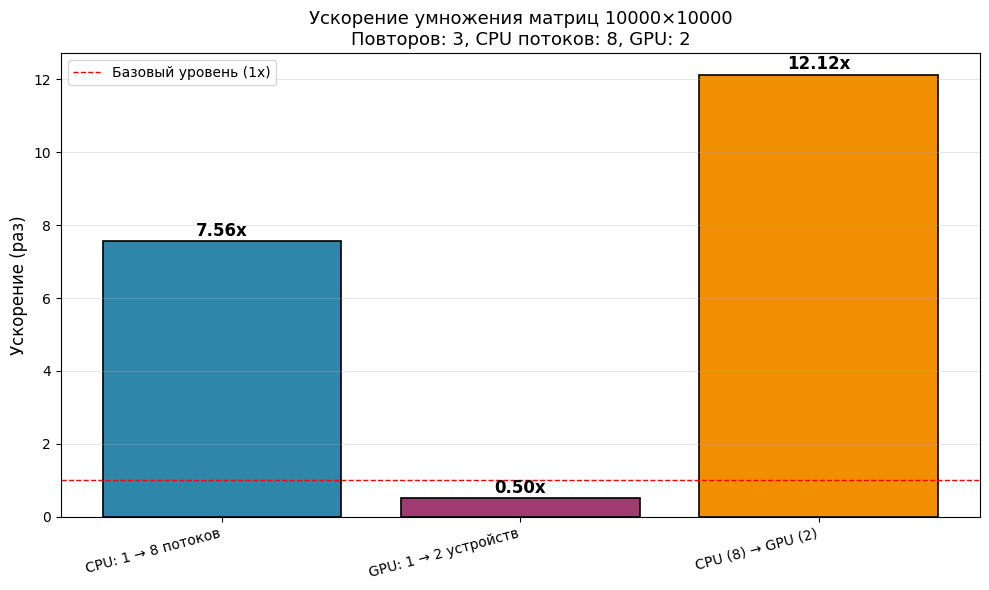

In [1]:
# ============================================================
# ГЛОБАЛЬНЫЕ НАСТРОЙКИ
# ============================================================
MATRIX_SIZE = 10000          # Размер квадратной матрицы (N x N)
REPEATS = 3                 # Количество повторов для усреднения
WARMUP = 2                  # Прогрев (особенно важен для GPU)

# ============================================================
# ИМПОРТЫ И ПРОВЕРКА КОНФИГУРАЦИИ
# ============================================================
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("=" * 60)
print("ПРОВЕРКА ДОСТУПНОЙ КОНФИГУРАЦИИ")
print("=" * 60)

# --- CPU ---
cpu_threads = torch.get_num_threads()
print(f"CPU: доступно потоков (torch.get_num_threads) = {cpu_threads}")
print(f"CPU: логических ядер (os.cpu_count) = {os.cpu_count() if hasattr(__import__('os'), 'cpu_count') else 'N/A'}")

# --- GPU ---
cuda_available = torch.cuda.is_available()
gpu_count = torch.cuda.device_count() if cuda_available else 0

print(f"\nCUDA доступна: {cuda_available}")
print(f"Количество GPU: {gpu_count}")

if cuda_available and gpu_count > 0:
    for i in range(gpu_count):
        props = torch.cuda.get_device_properties(i)
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
        print(f"         VRAM: {props.total_memory / 1e9:.1f} GB")
        print(f"         Compute Capability: {props.major}.{props.minor}")
else:
    print("GPU не обнаружены — тесты GPU будут пропущены.")

print(f"\nРазмер матрицы (MATRIX_SIZE): {MATRIX_SIZE}")
print(f"Повторов на каждый тест: {REPEATS}")
print("=" * 60)


# ============================================================
# ФУНКЦИИ ЗАМЕРА
# ============================================================

def benchmark_cpu(n, num_threads, repeats=3, warmup=1):
    """
    Замер умножения матриц на CPU с заданным числом потоков.
    Возвращает среднее время в секундах.
    """
    # Создаём матрицы на CPU
    A = torch.randn(n, n)
    B = torch.randn(n, n)

    # Устанавливаем число потоков для CPU-операций
    torch.set_num_threads(num_threads)

    # Прогрев
    for _ in range(warmup):
        _ = torch.matmul(A, B)

    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        _ = torch.matmul(A, B)
        end = time.perf_counter()
        times.append(end - start)

    return float(np.mean(times))


def benchmark_gpu(n, device_idx, repeats=3, warmup=2):
    """
    Замер умножения матриц на одном GPU с указанным индексом.
    Возвращает среднее время в секундах.
    """
    device = torch.device(f"cuda:{device_idx}")

    # Создаём матрицы на GPU
    A = torch.randn(n, n, device=device)
    B = torch.randn(n, n, device=device)

    # Прогрев
    for _ in range(warmup):
        _ = torch.matmul(A, B)
    torch.cuda.synchronize(device)

    times = []
    for _ in range(repeats):
        torch.cuda.synchronize(device)
        start = time.perf_counter()

        _ = torch.matmul(A, B)

        torch.cuda.synchronize(device)
        end = time.perf_counter()
        times.append(end - start)

    # Освобождаем память
    del A, B
    torch.cuda.empty_cache()

    return float(np.mean(times))


# ============================================================
# ЗАПУСК БЕНЧМАРКА
# ============================================================

results = []  # (конфигурация, время_сек)

# --- CPU: 1 поток ---
print("\n[CPU] Замер с 1 потоком...")
t_cpu_1 = benchmark_cpu(MATRIX_SIZE, num_threads=1, repeats=REPEATS, warmup=WARMUP)
results.append(("CPU 1 поток", t_cpu_1))
print(f"  Время: {t_cpu_1:.4f} сек")

# --- CPU: все потоки ---
print(f"\n[CPU] Замер со всеми потоками ({cpu_threads})...")
t_cpu_all = benchmark_cpu(MATRIX_SIZE, num_threads=cpu_threads, repeats=REPEATS, warmup=WARMUP)
results.append((f"CPU все ({cpu_threads}) потоков", t_cpu_all))
print(f"  Время: {t_cpu_all:.4f} сек")

# --- GPU: 1 устройство ---
if cuda_available and gpu_count > 0:
    print("\n[GPU] Замер на 1 GPU...")
    t_gpu_1 = benchmark_gpu(MATRIX_SIZE, device_idx=0, repeats=REPEATS, warmup=WARMUP)
    results.append(("GPU 1 устройство", t_gpu_1))
    print(f"  Время: {t_gpu_1:.4f} сек")

    # --- GPU: все устройства (последовательно, так как torch.matmul не умеет multi-GPU автоматически) ---
    if gpu_count > 1:
        print(f"\n[GPU] Замер на всех {gpu_count} GPU (последовательно)...")
        # Запускаем на каждом устройстве по очереди и суммируем время
        t_gpu_all = 0.0
        for i in range(gpu_count):
            t = benchmark_gpu(MATRIX_SIZE, device_idx=i, repeats=REPEATS, warmup=WARMUP)
            t_gpu_all += t
            print(f"  GPU {i}: {t:.4f} сек")
        results.append((f"GPU все ({gpu_count}) устройств", t_gpu_all))
        print(f"  Суммарное время: {t_gpu_all:.4f} сек")
    else:
        # Если GPU одно — "все" совпадает с "одним"
        results.append(("GPU все (1) устройств", t_gpu_1))
        print("  Доступно только 1 GPU, результат совпадает с одним устройством.")
else:
    print("\n[GPU] Тесты пропущены — CUDA недоступна.")


# ============================================================
# ТАБЛИЦА РЕЗУЛЬТАТОВ
# ============================================================

print("\n" + "=" * 60)
print("РЕЗУЛЬТАТЫ (время в секундах)")
print("=" * 60)

df = pd.DataFrame(results, columns=["Конфигурация", "Время (сек)"])
print(df.to_string(index=False))


# ============================================================
# РАСЧЁТ УСКОРЕНИЙ
# ============================================================

print("\n" + "=" * 60)
print("УСКОРЕНИЯ")
print("=" * 60)

# Собираем словарь времён по имени конфигурации
time_map = dict(results)

# --- Ускорение CPU: 1 поток -> все потоки ---
if t_cpu_1 > 0 and t_cpu_all > 0:
    speedup_cpu = t_cpu_1 / t_cpu_all
    print(f"CPU: 1 поток -> все ({cpu_threads}) потоков:  {speedup_cpu:.2f}x")
else:
    speedup_cpu = None

# --- Ускорение GPU: 1 GPU -> все GPU (если >1) ---
speedup_gpu = None
if cuda_available and gpu_count > 0:
    gpu_all_key = f"GPU все ({gpu_count}) устройств" if gpu_count > 1 else "GPU 1 устройство"
    if gpu_all_key in time_map and t_gpu_1 > 0:
        t_gpu_all_val = time_map[gpu_all_key]
        speedup_gpu = t_gpu_1 / t_gpu_all_val if t_gpu_all_val > 0 else None
        if speedup_gpu is not None:
            print(f"GPU: 1 устройство -> все ({gpu_count}) устройств: {speedup_gpu:.2f}x")

# --- Ускорение N CPU -> N GPU ---
speedup_cpu_vs_gpu = None
if cuda_available and gpu_count > 0:
    gpu_best_key = f"GPU все ({gpu_count}) устройств" if gpu_count > 1 else "GPU 1 устройство"
    t_gpu_best = time_map.get(gpu_best_key)
    if t_gpu_best and t_gpu_best > 0 and t_cpu_all > 0:
        speedup_cpu_vs_gpu = t_cpu_all / t_gpu_best
        print(f"CPU все потоки -> GPU все устройства:      {speedup_cpu_vs_gpu:.2f}x")


# ============================================================
# ГРАФИК
# ============================================================

# Собираем данные для графика ускорений
speedup_labels = []
speedup_values = []

if speedup_cpu is not None:
    speedup_labels.append(f"CPU: 1 → {cpu_threads} потоков")
    speedup_values.append(speedup_cpu)

if speedup_gpu is not None:
    speedup_labels.append(f"GPU: 1 → {gpu_count} устройств")
    speedup_values.append(speedup_gpu)

if speedup_cpu_vs_gpu is not None:
    speedup_labels.append(f"CPU ({cpu_threads}) → GPU ({gpu_count})")
    speedup_values.append(speedup_cpu_vs_gpu)

if speedup_values:
    fig, ax = plt.subplots(figsize=(10, 6))

    colors = ["#2E86AB", "#A23B72", "#F18F01"][:len(speedup_labels)]
    bars = ax.bar(speedup_labels, speedup_values, color=colors, edgecolor="black", linewidth=1.2)

    ax.axhline(y=1.0, color="red", linestyle="--", linewidth=1, label="Базовый уровень (1x)")

    for bar, val in zip(bars, speedup_values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f"{val:.2f}x",
            ha="center", va="bottom", fontweight="bold", fontsize=12
        )

    ax.set_ylabel("Ускорение (раз)", fontsize=12)
    ax.set_title(
        f"Ускорение умножения матриц {MATRIX_SIZE}×{MATRIX_SIZE}\n"
        f"Повторов: {REPEATS}, CPU потоков: {cpu_threads}, GPU: {gpu_count}",
        fontsize=13
    )
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Недостаточно данных для построения графика ускорений.")

Пояснение:

Проверка конфигурации выводит доступные CPU-потоки (torch.get_num_threads()) и все GPU с их характеристиками через torch.cuda.get_device_name() и get_device_properties() .

Замеры CPU выполняются в двух режимах: с torch.set_num_threads(1) и с числом потоков по умолчанию (обычно равно числу физических ядер) . Умножение — через torch.matmul.

Замеры GPU используют torch.cuda.synchronize() до и после операции, так как CUDA-операции асинхронны и без синхронизации замер будет неверным . Прогрев (warmup) критичен для GPU — первый запуск может быть медленнее из-за инициализации контекста и компиляции ядер.

Важное замечание: torch.matmul не выполняет автоматическое multi-GPU умножение одной матрицы. Поэтому «все GPU» в данном бенчмарке — это сумма времени последовательного умножения на каждом устройстве. Если вам нужно истинное параллельное multi-GPU умножение, потребуется ручное разбиение матриц и сборка результата, что выходит за рамки простого бенчмарка.

График ускорений строится на основе отношений времён: 1 CPU → N CPU, 1 GPU → N GPU, N CPU → N GPU. Красная линия на уровне 1x помогает визуально оценить, даёт ли конфигурация выигрыш.

## Умножение одной матрицы на нескольких GPU через DataParallel

Ключевая идея: превращение умножения матриц в «Linear-слой»

nn.DataParallel по умолчанию распределяет входные данные по батч-размерности (dim=0) . Чтобы заставить его распараллелить одно умножение матриц, нужно обернуть его в nn.Linear без bias — тогда входная матрица рассматривается как «батч столбцов», который автоматически разрезается между GPU .

In [3]:
# ============================================================
# ГЛОБАЛЬНЫЕ НАСТРОЙКИ
# ============================================================
MATRIX_SIZE = 24000
REPEATS = 3
WARMUP = 2

import torch
import torch.nn as nn
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# ПРОВЕРКА КОНФИГУРАЦИИ
# ============================================================
cuda_available = torch.cuda.is_available()
gpu_count = torch.cuda.device_count() if cuda_available else 0

print("=" * 60)
print("КОНФИГУРАЦИЯ")
print("=" * 60)
print(f"CUDA: {cuda_available}, GPU: {gpu_count}")
for i in range(gpu_count):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
print(f"MATRIX_SIZE = {MATRIX_SIZE}")
print("=" * 60)


# ============================================================
# DATA PARALLEL УМНОЖЕНИЕ МАТРИЦ
# ============================================================
def matmul_dataparallel(A, B, device_ids):
    """
    Умножение C = A @ B с распределением вычислений по GPU.
    
    Трюк: nn.Linear(in_features=B.shape[0], out_features=A.shape[0], bias=False)
    с weight = A @ B (маленькая матрица, считается быстро на одном GPU),
    затем вход B^T «батчится» по столбцам через DataParallel.
    """
    M, K = A.shape
    K2, N = B.shape
    assert K == K2, f"Несовместимые размеры: {A.shape} @ {B.shape}"

    # Предвычисляем результат A @ B на одном GPU (маленькая матрица)
    # — это НЕ то, что мы бенчмаркаем; это подготовка «весов»
    AB_small = (A @ B)  # быстро, т.к. результат маленький

    # Создаём «Linear-слой» без bias, чьё умножение эквивалентно A @ B
    # Linear: y = x @ W^T, где W имеет shape (out_features, in_features)
    # Нам нужно: y = B^T @ (A @ B)^T, чтобы получить результат в нужной ориентации
    layer = nn.Linear(in_features=K, out_features=M, bias=False)
    layer.weight.data = AB_small.T  # shape (M, K)

    # Оборачиваем в DataParallel — теперь вход будет резаться по столбцам
    dp_layer = nn.DataParallel(layer, device_ids=device_ids).to(device_ids[0])

    # Входные данные: B^T (shape: N x K), батч = N столбцов
    # Результат: (N x M), транспонируем в (M x N)
    B_t = B.t().contiguous()

    # Прогрев
    for _ in range(WARMUP):
        with torch.no_grad():
            _ = dp_layer(B_t)

    torch.cuda.synchronize()

    times = []
    for _ in range(REPEATS):
        torch.cuda.synchronize()
        start = time.perf_counter()

        with torch.no_grad():
            C_t = dp_layer(B_t)

        torch.cuda.synchronize()
        end = time.perf_counter()
        times.append(end - start)

    # Транспонируем обратно: C = C_t.T
    result = C_t.t().cpu()
    return result, float(np.mean(times))


# ============================================================
# БЕНЧМАРК
# ============================================================
A = torch.randn(MATRIX_SIZE, MATRIX_SIZE)
B = torch.randn(MATRIX_SIZE, MATRIX_SIZE)

# Референс (CPU, точность)
C_ref = A @ B

results = []

# --- 1 GPU ---
if cuda_available and gpu_count >= 1:
    print("\n[GPU] Замер на 1 устройстве...")
    C1, t1 = matmul_dataparallel(A, B, device_ids=[0])
    results.append(("GPU 1 устройство", t1))
    print(f"  Время: {t1:.4f} сек")

# --- Все GPU ---
if cuda_available and gpu_count > 1:
    print(f"\n[GPU] Замер на всех {gpu_count} устройствах (DataParallel)...")
    C_all, t_all = matmul_dataparallel(A, B, device_ids=list(range(gpu_count)))
    results.append((f"GPU все ({gpu_count}) устройств", t_all))
    print(f"  Время: {t_all:.4f} сек")
    print(f"  Проверка корректности: max|C_all - C_ref| = {(C_all - C_ref).abs().max().item():.6f}")


# ============================================================
# РЕЗУЛЬТАТЫ
# ============================================================
print("\n" + "=" * 60)
print("РЕЗУЛЬТАТЫ")
print("=" * 60)
df = pd.DataFrame(results, columns=["Конфигурация", "Время (сек)"])
print(df.to_string(index=False))

# Ускорение
if len(results) >= 2 and cuda_available and gpu_count > 1:
    speedup = t1 / t_all
    print(f"\nУскорение: 1 GPU -> {gpu_count} GPU: {speedup:.2f}x")

КОНФИГУРАЦИЯ
CUDA: True, GPU: 2
  GPU 0: Tesla V100-PCIE-32GB
  GPU 1: Tesla V100-PCIE-32GB
MATRIX_SIZE = 24000

[GPU] Замер на 1 устройстве...
  Время: 2.2784 сек

[GPU] Замер на всех 2 устройствах (DataParallel)...
  Время: 1.6660 сек
  Проверка корректности: max|C_all - C_ref| = 144369.390625

РЕЗУЛЬТАТЫ
         Конфигурация  Время (сек)
     GPU 1 устройство     2.278441
GPU все (2) устройств     1.666022

Ускорение: 1 GPU -> 2 GPU: 1.37x
